In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from win_prob import *


In [6]:
df = pd.read_csv('Wimbledon_featured_matches.csv')

In [10]:
sets = df["p1_sets"].astype(str) + "-" + df["p2_sets"].astype(str)
games = df["p1_games"].astype(str) + "-" + df["p2_games"].astype(str)
points = df["p1_score"].astype(str) + "-" + df["p2_score"].astype(str)
server = df["server"]
p = 0.655161325 
df["win_prob"] = list(map(lambda x,y,z: win_prob(x,y,z), sets, games, points))
df["aheadness"] = list(map(lambda x,y,z,a: find_metric(x, y, z, a, p), sets, games, points, server))

In [33]:
# cleaning
df['elapsed_time'] = pd.to_timedelta(df['elapsed_time'])
df['elapsed_time'] = df['elapsed_time'].dt.total_seconds()

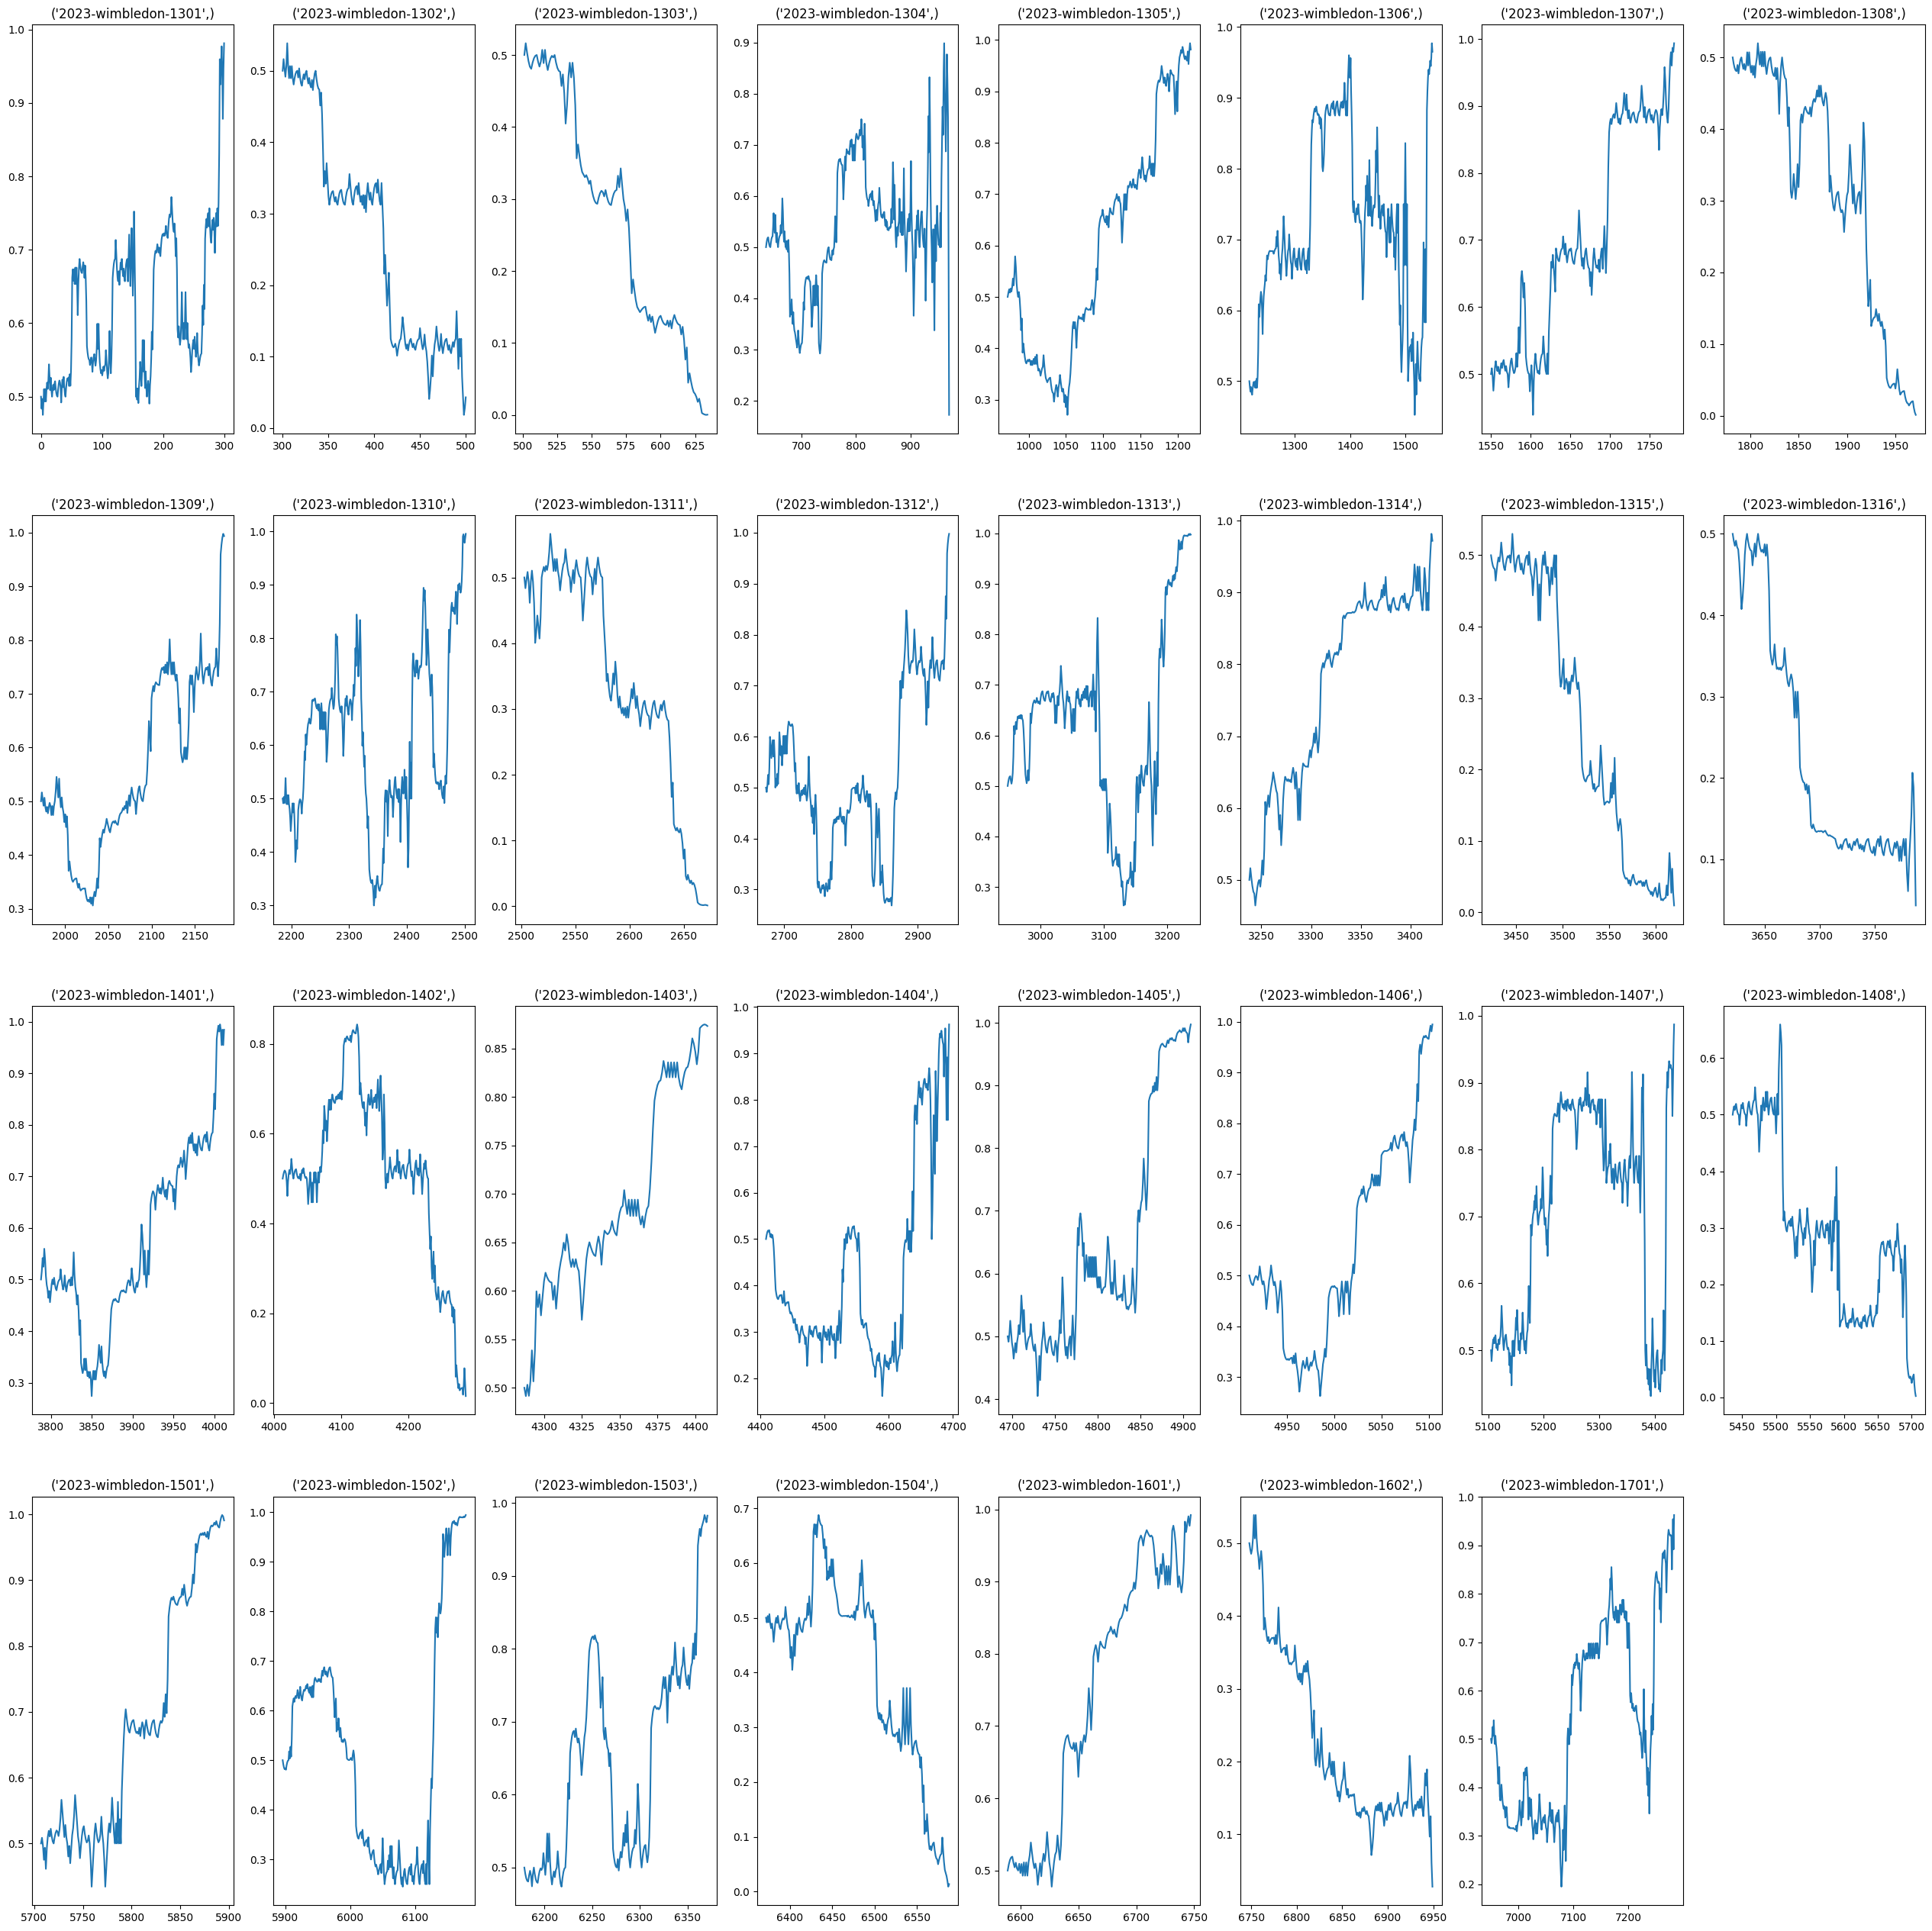

In [11]:
plt.figure(figsize=(32,32))
i = 0
for name, group in df.groupby(['match_id']):
    i += 1
    plt.subplot(4, 8, i)
    plt.plot(group.index, group['aheadness'])
    plt.title(name)